# Data Inspection and Basic Cleaning

## import and setup

In [1]:
import pandas as pd
import numpy as np
import yaml
from pathlib import Path

In [2]:
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

## data load and column rename

In [3]:
df = pd.read_csv('../data/raw/incident_event_log.csv')

In [4]:
df.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 9:52,6/3/2016 10:00


In [5]:
schema = yaml.safe_load(open('../configs/schema.yaml'))
schema_col = schema['raw_to_canonical']

In [6]:
schema['timestamp_cols']

['opened_timestamp',
 'creator_timestamp',
 'update_timestamp',
 'resolved_timestamp',
 'closed_timestamp']

In [7]:
df = df.rename(columns=schema_col)

In [8]:
df.head()

,case_id,case_status,is_open,reassignment_total,reopen_total,system_update_count,met_deadline,affected_user_id,reporter_user_id,opened_timestamp,creator_agent_id,creator_timestamp,update_agent_id,update_timestamp,contact_channel,location_id,category,subcategory,issue_type_id,asset_id,impact_level,urgency_level,computed_priority_level,assigned_team_id,assigned_agent_id,used_knowledge_base,priority_confirmed,notify_email,issue_id,change_request_id,vendor_id,caused_by_ref_id,closed_code,resolved_by_agent_id,resolved_timestamp,closed_timestamp
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 9:52,6/3/2016 10:00


## treating sentinel values (?)

In [9]:
# replace missing values "?" with NaN
df = df.replace(schema.get("missing_values").get('token'), np.nan)

In [10]:
df.head()

,case_id,case_status,is_open,reassignment_total,reopen_total,system_update_count,met_deadline,affected_user_id,reporter_user_id,opened_timestamp,creator_agent_id,creator_timestamp,update_agent_id,update_timestamp,contact_channel,location_id,category,subcategory,issue_type_id,asset_id,impact_level,urgency_level,computed_priority_level,assigned_team_id,assigned_agent_id,used_knowledge_base,priority_confirmed,notify_email,issue_id,change_request_id,vendor_id,caused_by_ref_id,closed_code,resolved_by_agent_id,resolved_timestamp,closed_timestamp
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,1/3/2016 9:52,6/3/2016 10:00


In [11]:
df[schema['timestamp_cols']].dtypes

opened_timestamp      object
creator_timestamp     object
update_timestamp      object
resolved_timestamp    object
closed_timestamp      object
dtype: object

In [12]:
dayfirst = schema.get("parsing", {}).get("timestamp_day_first", True)

In [13]:
schema.get('timestamp_cols')

['opened_timestamp',
 'creator_timestamp',
 'update_timestamp',
 'resolved_timestamp',
 'closed_timestamp']

In [14]:
# timestamps as datetimes with day-first
for c in schema.get('timestamp_cols'):
    df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=dayfirst)


## treating magic number 

In [15]:
df.head()

,case_id,case_status,is_open,reassignment_total,reopen_total,system_update_count,met_deadline,affected_user_id,reporter_user_id,opened_timestamp,creator_agent_id,creator_timestamp,update_agent_id,update_timestamp,contact_channel,location_id,category,subcategory,issue_type_id,asset_id,impact_level,urgency_level,computed_priority_level,assigned_team_id,assigned_agent_id,used_knowledge_base,priority_confirmed,notify_email,issue_id,change_request_id,vendor_id,caused_by_ref_id,closed_code,resolved_by_agent_id,resolved_timestamp,closed_timestamp
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 21,2016-02-29 01:23:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 642,2016-02-29 08:53:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 804,2016-02-29 11:29:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 908,2016-03-05 12:00:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 56,NaN,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 746,2016-02-29 04:57:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,NaN,NaN,NaN,NaN,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00


In [16]:
df.shape

(141712, 36)

In [17]:
df.nunique()

case_id                    24918
case_status                    9
is_open                        2
reassignment_total            28
reopen_total                   9
system_update_count          115
met_deadline                   2
affected_user_id            5244
reporter_user_id             207
opened_timestamp           19849
creator_agent_id             185
creator_timestamp          11552
update_agent_id              846
update_timestamp           50664
contact_channel                5
location_id                  224
category                      58
subcategory                  254
issue_type_id                525
asset_id                      50
impact_level                   3
urgency_level                  3
computed_priority_level        4
assigned_team_id              78
assigned_agent_id            234
used_knowledge_base            2
priority_confirmed             2
notify_email                   2
issue_id                     252
change_request_id            181
vendor_id 

In [18]:
print((df.nunique() <= 10).sum(), 
    (df.nunique() <= 50).sum(),)

13 16


### checking categorical col visually

In [19]:
for col in df.loc[:, df.nunique() <= 10].columns:
    print(col, ": ", df[col].unique(), end='\n\n')

case_status :  ['New' 'Resolved' 'Closed' 'Active' 'Awaiting User Info'
 'Awaiting Problem' 'Awaiting Vendor' 'Awaiting Evidence' '-100']

is_open :  [ True False]

reopen_total :  [0 1 2 3 4 5 6 7 8]

met_deadline :  [ True False]

contact_channel :  ['Phone' 'Email' 'Self service' 'Direct opening' 'IVR']

impact_level :  ['2 - Medium' '1 - High' '3 - Low']

urgency_level :  ['2 - Medium' '3 - Low' '1 - High']

computed_priority_level :  ['3 - Moderate' '2 - High' '4 - Low' '1 - Critical']

used_knowledge_base :  [ True False]

priority_confirmed :  [False  True]

notify_email :  ['Do Not Notify' 'Send Email']

vendor_id :  [nan 'code 8s' 'Vendor 3' 'Vendor 2' 'Vendor 1']

caused_by_ref_id :  [nan 'CHG0000132' 'CHG0000097' 'CHG0001327']



In [20]:
df.select_dtypes(include='int')

,reassignment_total,reopen_total,system_update_count
0,0,0,0
1,0,0,2
2,0,0,3
3,0,0,4
4,0,0,0
...,...,...,...
141707,1,0,4
141708,0,0,0
141709,1,0,1
141710,1,0,2


### magic values in numeric data - sanity check

In [21]:
(df.select_dtypes(include='int') < 0).sum() # neither of them can have -ve value 

reassignment_total     0
reopen_total           0
system_update_count    0
dtype: int64

### check for cateogrical col with regex

In [22]:
df.loc[:, df.nunique() > 10].select_dtypes(exclude=int).columns

Index(['case_id', 'affected_user_id', 'reporter_user_id', 'opened_timestamp',
       'creator_agent_id', 'creator_timestamp', 'update_agent_id',
       'update_timestamp', 'location_id', 'category', 'subcategory',
       'issue_type_id', 'asset_id', 'assigned_team_id', 'assigned_agent_id',
       'issue_id', 'change_request_id', 'closed_code', 'resolved_by_agent_id',
       'resolved_timestamp', 'closed_timestamp'],
      dtype='object')

In [23]:
df['issue_type_id']

0          Symptom 72
1          Symptom 72
2          Symptom 72
3          Symptom 72
4         Symptom 471
             ...     
141707    Symptom 494
141708    Symptom 494
141709    Symptom 494
141710    Symptom 494
141711    Symptom 494
Name: issue_type_id, Length: 141712, dtype: object

In [24]:
regx = r'^[A-Z]{3}\d{7}$'
df['case_id'].str.contains(regx).sum()

np.int64(141712)

In [25]:
df['case_id'].str.match(r'^INC\d{7}$').sum()

np.int64(141712)

In [26]:
df['affected_user_id'].str.match(r'^Caller \d+$', na=True).sum()

np.int64(141712)

In [27]:
df['reporter_user_id'].str.match(r'^Opened by \d+$', na=True).sum()

np.int64(4835)

In [28]:
df['location_id'].str.match(r'^Location \d+$', na=True).sum()

np.int64(141712)

In [29]:
rem_col = df.loc[:, df.nunique() > 10].select_dtypes(exclude=int).columns # remaining columns
rem_col = rem_col.drop(['opened_timestamp', 'creator_timestamp', 'update_timestamp',
              'resolved_timestamp', 'closed_timestamp'])
df[rem_col].head(10)

,case_id,affected_user_id,reporter_user_id,creator_agent_id,update_agent_id,location_id,category,subcategory,issue_type_id,asset_id,assigned_team_id,assigned_agent_id,issue_id,change_request_id,closed_code,resolved_by_agent_id
0,INC0000045,Caller 2403,Opened by 8,Created by 6,Updated by 21,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,Group 56,NaN,NaN,NaN,code 5,Resolved by 149
1,INC0000045,Caller 2403,Opened by 8,Created by 6,Updated by 642,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,Group 56,NaN,NaN,NaN,code 5,Resolved by 149
2,INC0000045,Caller 2403,Opened by 8,Created by 6,Updated by 804,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,Group 56,NaN,NaN,NaN,code 5,Resolved by 149
3,INC0000045,Caller 2403,Opened by 8,Created by 6,Updated by 908,Location 143,Category 55,Subcategory 170,Symptom 72,NaN,Group 56,NaN,NaN,NaN,code 5,Resolved by 149
4,INC0000047,Caller 2403,Opened by 397,Created by 171,Updated by 746,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,Group 70,Resolver 89,NaN,NaN,code 5,Resolved by 81
5,INC0000047,Caller 2403,Opened by 397,Created by 171,Updated by 21,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,Group 24,Resolver 31,NaN,NaN,code 5,Resolved by 81
6,INC0000047,Caller 2403,Opened by 397,Created by 171,Updated by 21,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,Group 24,Resolver 31,NaN,NaN,code 5,Resolved by 81
7,INC0000047,Caller 2403,Opened by 397,Created by 171,Updated by 804,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,Group 24,Resolver 31,NaN,NaN,code 5,Resolved by 81
8,INC0000047,Caller 2403,Opened by 397,Created by 171,Updated by 703,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,Group 24,Resolver 31,NaN,NaN,code 5,Resolved by 81
9,INC0000047,Caller 2403,Opened by 397,Created by 171,Updated by 332,Location 165,Category 40,Subcategory 215,Symptom 471,NaN,Group 24,Resolver 31,NaN,NaN,code 5,Resolved by 81


In [30]:
# all column with regex pattern or null
for col in rem_col:
    valid_record = (df[col].isna() | df[col].str.match(r'^[A-Za-z\s_]+\d+$', na=False)).sum()
    print(col, valid_record)

case_id 141712
affected_user_id 141712
reporter_user_id 141712
creator_agent_id 141712
update_agent_id 141712
location_id 141712
category 141712
subcategory 141712
issue_type_id 141712
asset_id 141712
assigned_team_id 141712
assigned_agent_id 141712
issue_id 141712
change_request_id 141712
closed_code 141712
resolved_by_agent_id 141712


In [31]:
for col in rem_col:
    extracted = df[col].str.extract(r'^([A-Za-z\s_]+)', expand=False)
    valid_record = extracted.dropna().unique()
    print(col, ": ", valid_record)

case_id :  ['INC']
affected_user_id :  ['Caller ']
reporter_user_id :  ['Opened by  ']
creator_agent_id :  ['Created by ']
update_agent_id :  ['Updated by ']
location_id :  ['Location ']
category :  ['Category ']
subcategory :  ['Subcategory ']
issue_type_id :  ['Symptom ']
asset_id :  ['cmdb_ci ']
assigned_team_id :  ['Group ']
assigned_agent_id :  ['Resolver ']
issue_id :  ['Problem ID  ']
change_request_id :  ['CHG']
closed_code :  ['code ']
resolved_by_agent_id :  ['Resolved by ']


`case_status` and `ventor_id` have magic numbers -100, and code 8s respectively

In [32]:
status_magic_idx = df['case_status'].eq('-100')
status_magic_case_id = df[status_magic_idx]['case_id'].unique()
status_magic_case_id.size

2

In [33]:
status_magic_idx = df['vendor_id'].eq('code 8s')
status_magic_case_id = df[status_magic_idx]['case_id'].unique()
status_magic_case_id.size

50

In [34]:
status_magic_idx = df['case_status'].eq('-100')
status_magic_case_id = df[status_magic_idx]['case_id'].unique()
df_magic = df.loc[df['case_id'].isin(status_magic_case_id)]
df_magic[['case_id', 'case_status']]

,case_id,case_status
115640,INC0028089,New
115641,INC0028089,-100
115642,INC0028089,-100
115643,INC0028089,Resolved
115644,INC0028089,Resolved
115645,INC0028089,Closed
124503,INC0030413,New
124504,INC0030413,New
124505,INC0030413,Active
124506,INC0030413,Active


In [35]:
status_magic_idx = df['vendor_id'].eq('code 8s')
status_magic_case_id = df[status_magic_idx]['case_id'].unique()
status_magic_df = df.loc[df['case_id'].isin(status_magic_case_id)]

# count 
status_magic_df.groupby('case_id')['vendor_id'].unique()

case_id
INC0001845    [nan, code 8s]
INC0002099    [nan, code 8s]
INC0002104    [nan, code 8s]
INC0002332    [nan, code 8s]
INC0002336    [nan, code 8s]
INC0002559    [nan, code 8s]
INC0003216    [nan, code 8s]
INC0003228    [nan, code 8s]
INC0003258    [nan, code 8s]
INC0004123    [nan, code 8s]
INC0005008    [nan, code 8s]
INC0005213    [nan, code 8s]
INC0006165    [nan, code 8s]
INC0009186    [nan, code 8s]
INC0009537    [nan, code 8s]
INC0010272    [nan, code 8s]
INC0010418    [nan, code 8s]
INC0011175    [nan, code 8s]
INC0011177    [nan, code 8s]
INC0011178    [nan, code 8s]
INC0012044    [nan, code 8s]
INC0012984    [nan, code 8s]
INC0013219    [nan, code 8s]
INC0013636    [nan, code 8s]
INC0013833    [nan, code 8s]
INC0013946    [nan, code 8s]
INC0015087    [nan, code 8s]
INC0015098    [nan, code 8s]
INC0015283    [nan, code 8s]
INC0015300    [nan, code 8s]
INC0015847    [nan, code 8s]
INC0015927    [nan, code 8s]
INC0015945    [nan, code 8s]
INC0015951    [nan, code 8s]
INC001

In [36]:
# times vendor_id is null / considered as unknown
df.isna().sum()['vendor_id']

np.int64(141468)

* -100 in `case_status` is unknown and system default/error. This can be replaced with nan.
* code 8s in `vendor_id` can be actual value or system default/error. This needs to treated as seperate category as vendor is very sparse and mostly unknown.

### case_status and vendor_id magic number fix

In [37]:
df["case_status"] = df["case_status"].replace([-100, "-100"], "Unknown")

In [38]:
df["vendor_id"] = df["vendor_id"].replace({"code 8s": "VendorCode8s"})

In [39]:
df.columns

Index(['case_id', 'case_status', 'is_open', 'reassignment_total',
       'reopen_total', 'system_update_count', 'met_deadline',
       'affected_user_id', 'reporter_user_id', 'opened_timestamp',
       'creator_agent_id', 'creator_timestamp', 'update_agent_id',
       'update_timestamp', 'contact_channel', 'location_id', 'category',
       'subcategory', 'issue_type_id', 'asset_id', 'impact_level',
       'urgency_level', 'computed_priority_level', 'assigned_team_id',
       'assigned_agent_id', 'used_knowledge_base', 'priority_confirmed',
       'notify_email', 'issue_id', 'change_request_id', 'vendor_id',
       'caused_by_ref_id', 'closed_code', 'resolved_by_agent_id',
       'resolved_timestamp', 'closed_timestamp'],
      dtype='object')

In [40]:
(df.groupby('case_id')['met_deadline'].nunique() != 1).sum()

np.int64(9114)

In [41]:
df.groupby('case_id')['met_deadline'].unique() 

case_id
INC0000045           [True]
INC0000047           [True]
INC0000057           [True]
INC0000060           [True]
INC0000062    [True, False]
                  ...      
INC0120304           [True]
INC0120319           [True]
INC0120495           [True]
INC0120835           [True]
INC0121064           [True]
Name: met_deadline, Length: 24918, dtype: object

In [42]:
schema.get("raw_to_canonical", {}).get("incident_state")

'case_status'

## checks before canonical data for modeling

In [43]:
# update_timestamp are canonical ordering feature - can't afford to be nan
print(df["case_id"].isna().sum(), 
    df["update_timestamp"].isna().sum()
)

0 0


In [44]:
# the key (combination of below 3) should not have duplicates 
key_cols = ["case_id", "update_timestamp", "system_update_count"] 
df.duplicated(key_cols).sum()

np.int64(0)

In [45]:
(df.groupby("case_id")["met_deadline"].nunique() > 1).mean()

np.float64(0.36575969178906814)

In [46]:
# entries per case
df.groupby("case_id").size().describe()

count    24918.000000
mean         5.687134
std          3.677845
min          2.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         58.000000
dtype: float64

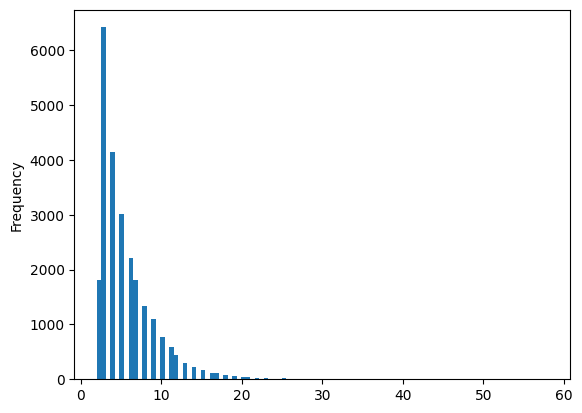

In [47]:
df.groupby("case_id").size().plot(kind='hist', bins=100);

Maximum 58 entries per case, with median being 

In [48]:
# timestamp converted properly
(df[schema["timestamp_cols"]] == pd.NaT).sum()

opened_timestamp      0
creator_timestamp     0
update_timestamp      0
resolved_timestamp    0
closed_timestamp      0
dtype: int64

In [49]:
df[schema["timestamp_cols"]].dtypes

opened_timestamp      datetime64[ns]
creator_timestamp     datetime64[ns]
update_timestamp      datetime64[ns]
resolved_timestamp    datetime64[ns]
closed_timestamp      datetime64[ns]
dtype: object